# Chương 4 - Phần 2: Đánh Giá Hiệu Năng Phân Loại Bằng ROC

**Thông tin học viên:**
- **Họ và tên:** Nguyễn Ngọc Anh  
- **Lớp:** CN22H  
- **Môn học:** Thị giác Máy tính (Computer Vision)  

---

## 1. Import Thư Viện & Tải Dữ Liệu

Tải kết quả tính toán khoảng cách của các cặp ảnh từ Phần 1.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 8]

data_path = "../data/processed/pairs_results.json"
if not os.path.exists(data_path):
    raise FileNotFoundError("Không tìm thấy dữ liệu. Hãy chạy notebook Phần 1 (wavelet_hashing.ipynb) trước!")

with open(data_path, "r") as f:
    data = json.load(f)

max_len_slide = data["max_len_slide"]
max_len_std = data["max_len_std"]
pairs_results = data["results"]
print(f"Đã tải {len(pairs_results)} kết quả so khớp cặp ảnh.")

Đã tải 20910 kết quả so khớp cặp ảnh.


## 2. Tính Toán Các Chỉ Số TPR, FPR & Accuracy

Xây dựng thuật toán tính toán ma trận nhầm lẫn tối ưu hóa bằng NumPy vectorization.

In [2]:
def evaluate_method(results, dist_key, max_dist):
    dists = np.array([res[dist_key] for res in results])
    gts = np.array([res["gt"] for res in results])
    
    tpr_list = []
    fpr_list = []
    best_acc = 0
    best_t = 0
    
    # Quét qua 101 điểm phân ngưỡng để tạo đồ thị ROC mịn
    thresholds = range(0, max_dist + 1, max(1, max_dist // 100))
    for T in thresholds:
        preds = (dists <= T).astype(int)
        
        tp = np.sum((preds == 1) & (gts == 1))
        fp = np.sum((preds == 1) & (gts == 0))
        tn = np.sum((preds == 0) & (gts == 0))
        fn = np.sum((preds == 0) & (gts == 1))
            
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        acc = (tp + tn) / len(results)
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)
        
        if acc > best_acc:
            best_acc = acc
            best_t = T
            
    return tpr_list, fpr_list, best_acc, best_t

tpr_slide, fpr_slide, acc_slide, t_slide = evaluate_method(pairs_results, "dist_slide", max_len_slide)
tpr_std, fpr_std, acc_std, t_std = evaluate_method(pairs_results, "dist_std", max_len_std)

print(f"Phương pháp Slide: Độ chính xác tốt nhất = {acc_slide*100:.2f}% tại ngưỡng T = {t_slide}")
print(f"Phương pháp wHash Chuẩn: Độ chính xác tốt nhất = {acc_std*100:.2f}% tại ngưỡng T = {t_std}")

Phương pháp Slide: Độ chính xác tốt nhất = 84.11% tại ngưỡng T = 2156
Phương pháp wHash Chuẩn: Độ chính xác tốt nhất = 94.62% tại ngưỡng T = 420


## 3. Vẽ Đường Cong ROC So Sánh

Vẽ biểu đồ và lưu kết quả vào thư mục `outputs/`.

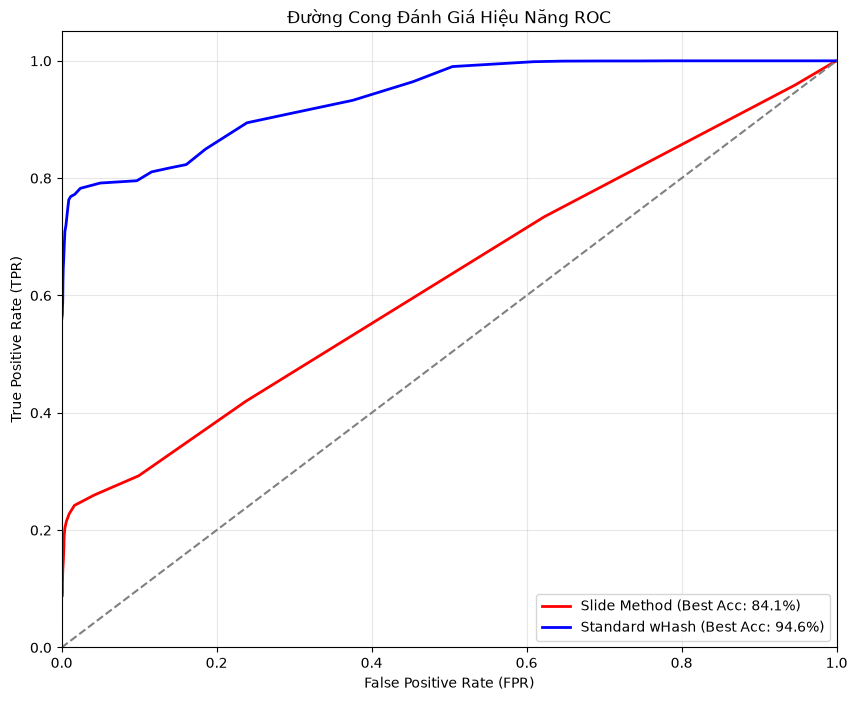

Đã lưu biểu đồ ROC thành công tại: ../outputs/roc_curve.png


In [3]:
os.makedirs("../outputs", exist_ok=True)

plt.figure(figsize=(10, 8))
plt.plot(fpr_slide, tpr_slide, color='red', lw=2, label=f'Slide Method (Best Acc: {acc_slide*100:.1f}%)')
plt.plot(fpr_std, tpr_std, color='blue', lw=2, label=f'Standard wHash (Best Acc: {acc_std*100:.1f}%)')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Đường Cong Đánh Giá Hiệu Năng ROC')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

roc_path = "../outputs/roc_curve.png"
plt.savefig(roc_path, dpi=300)
plt.show()
print(f"Đã lưu biểu đồ ROC thành công tại: {roc_path}")